<a href="https://colab.research.google.com/github/Meenarekha/Computer-Vision/blob/main/BackGround_Subtraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

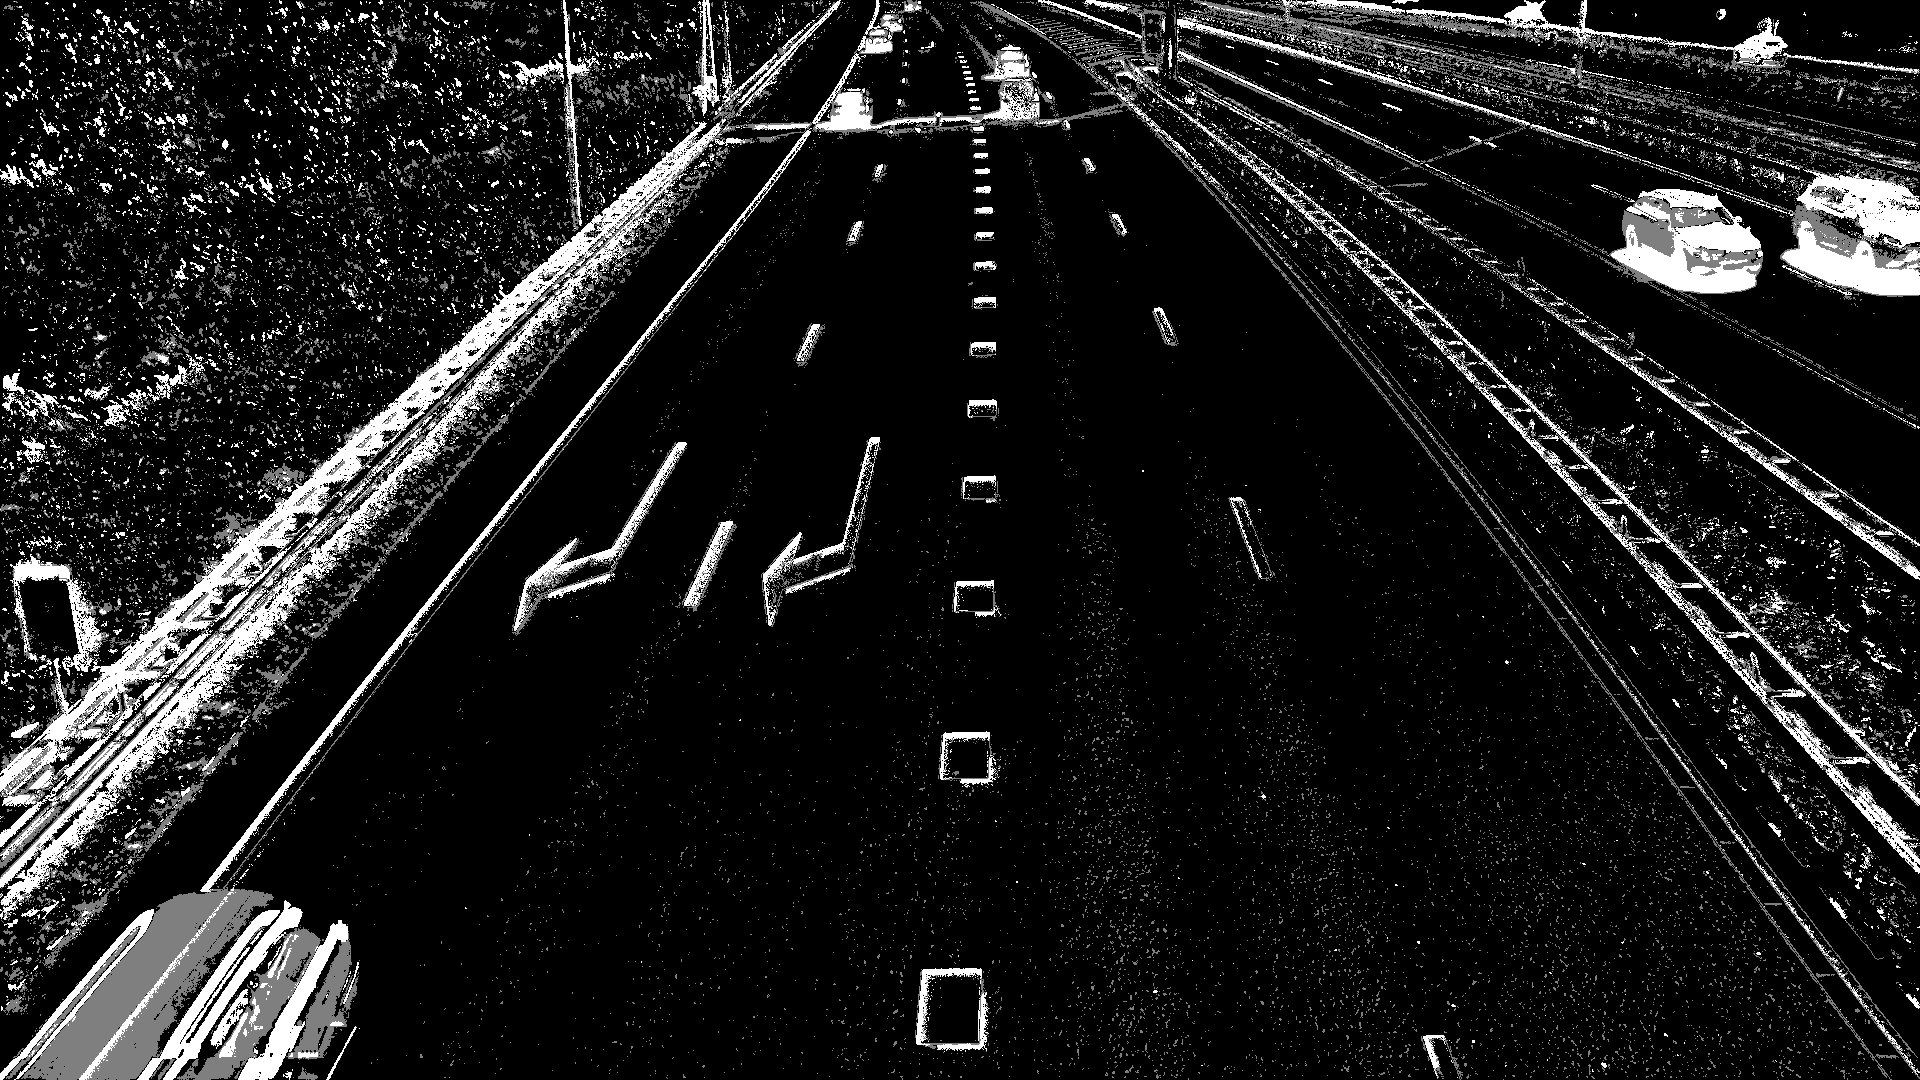

In [ ]:
import cv2
from IPython.display import display, clear_output
from PIL import Image

cap = cv2.VideoCapture(r'C:\Users\Meena\Videos\cv_bg_sub.mp4')
bg_subtractor = cv2.createBackgroundSubtractorKNN()

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    fg_mask = bg_subtractor.apply(frame)
    fg_img = Image.fromarray(fg_mask)

    clear_output(wait=True)
    display(fg_img)

cap.release()


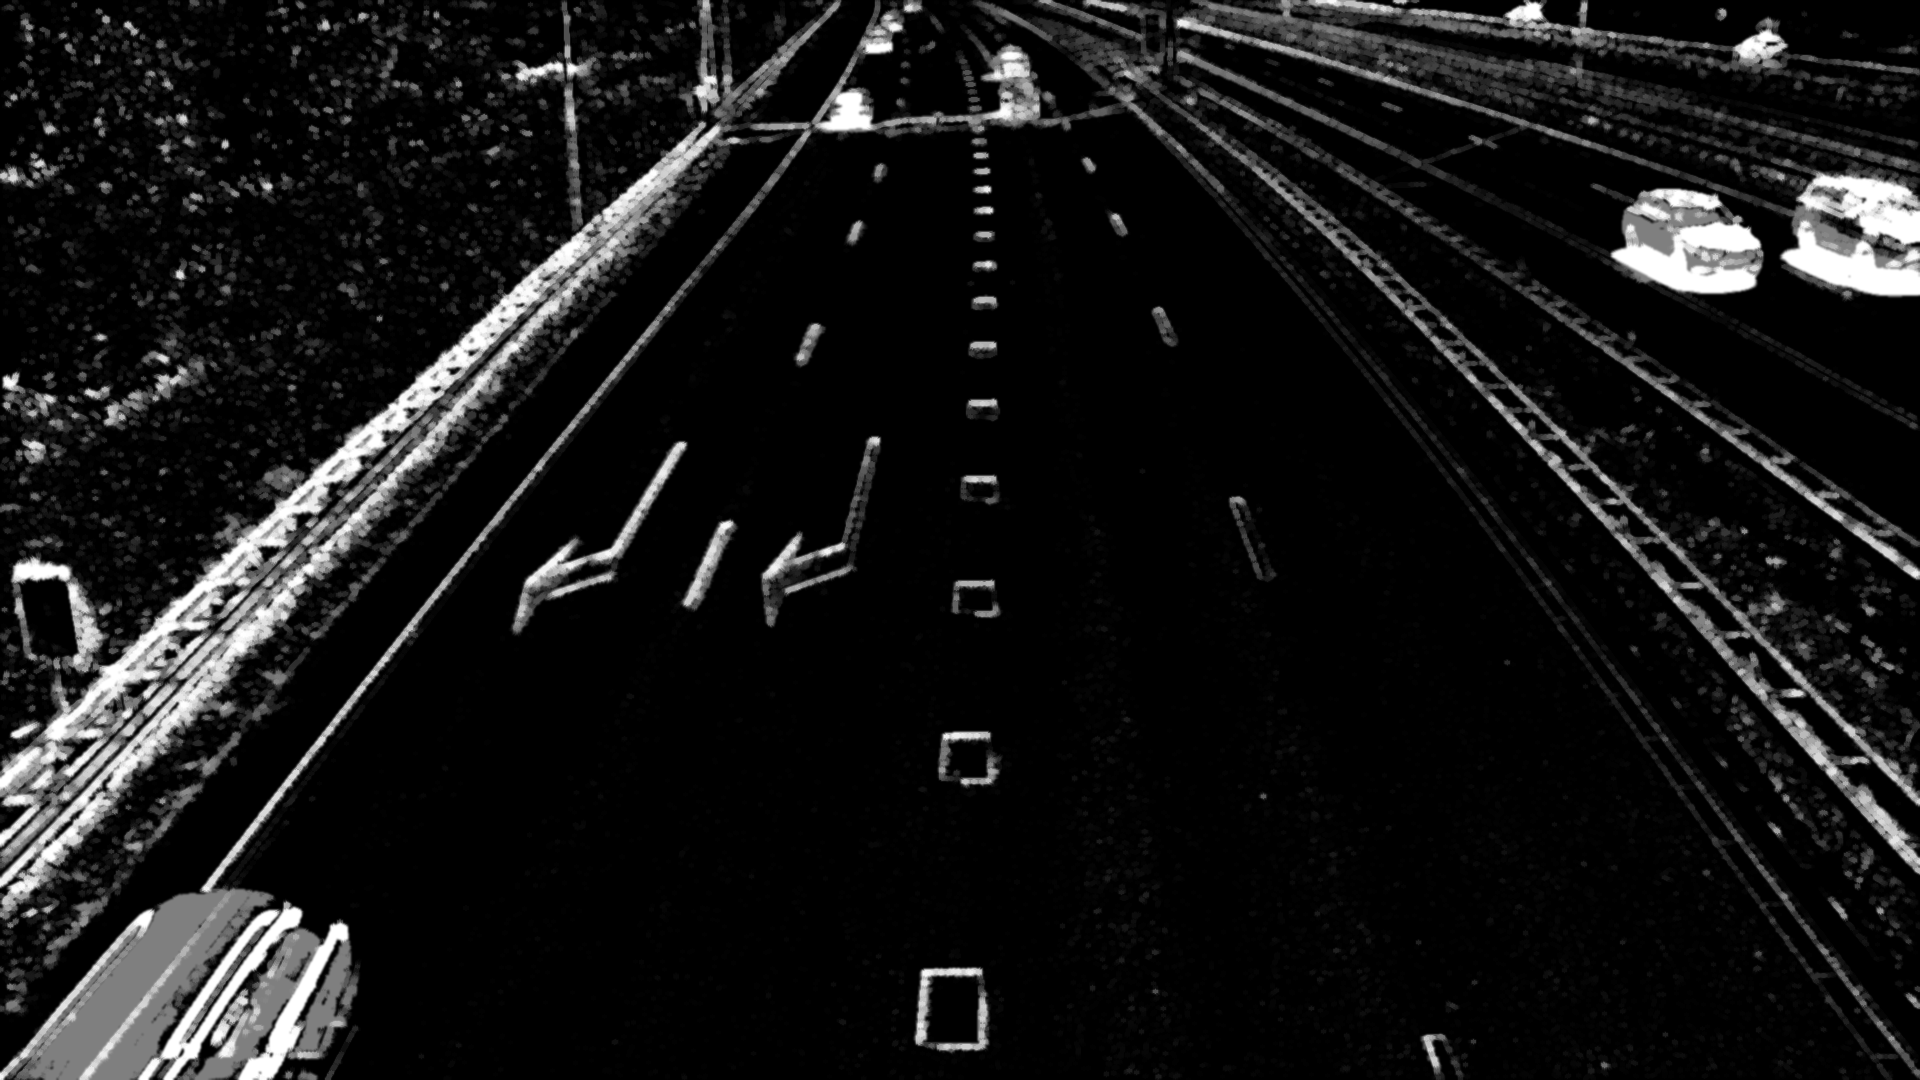

In [ ]:
import cv2
import numpy as np
from IPython.display import display, clear_output
from PIL import Image

# Load the video
cap = cv2.VideoCapture(r'C:\Users\Meena\Videos\cv_bg_sub.mp4')

# Initialize background subtractor
bg_subtractor = cv2.createBackgroundSubtractorKNN()

# Define kernel for morphological operations
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Apply background subtraction
    fg_mask = bg_subtractor.apply(frame)

    # Apply Gaussian Blur to smooth noise
    fg_mask = cv2.GaussianBlur(fg_mask, (5,5), 0)

    # Apply morphological operations (Opening) to remove small noise
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel)

    # Convert to displayable format
    fg_img = Image.fromarray(fg_mask)

    # Clear previous output and display new frame
    clear_output(wait=True)
    display(fg_img)

cap.release()


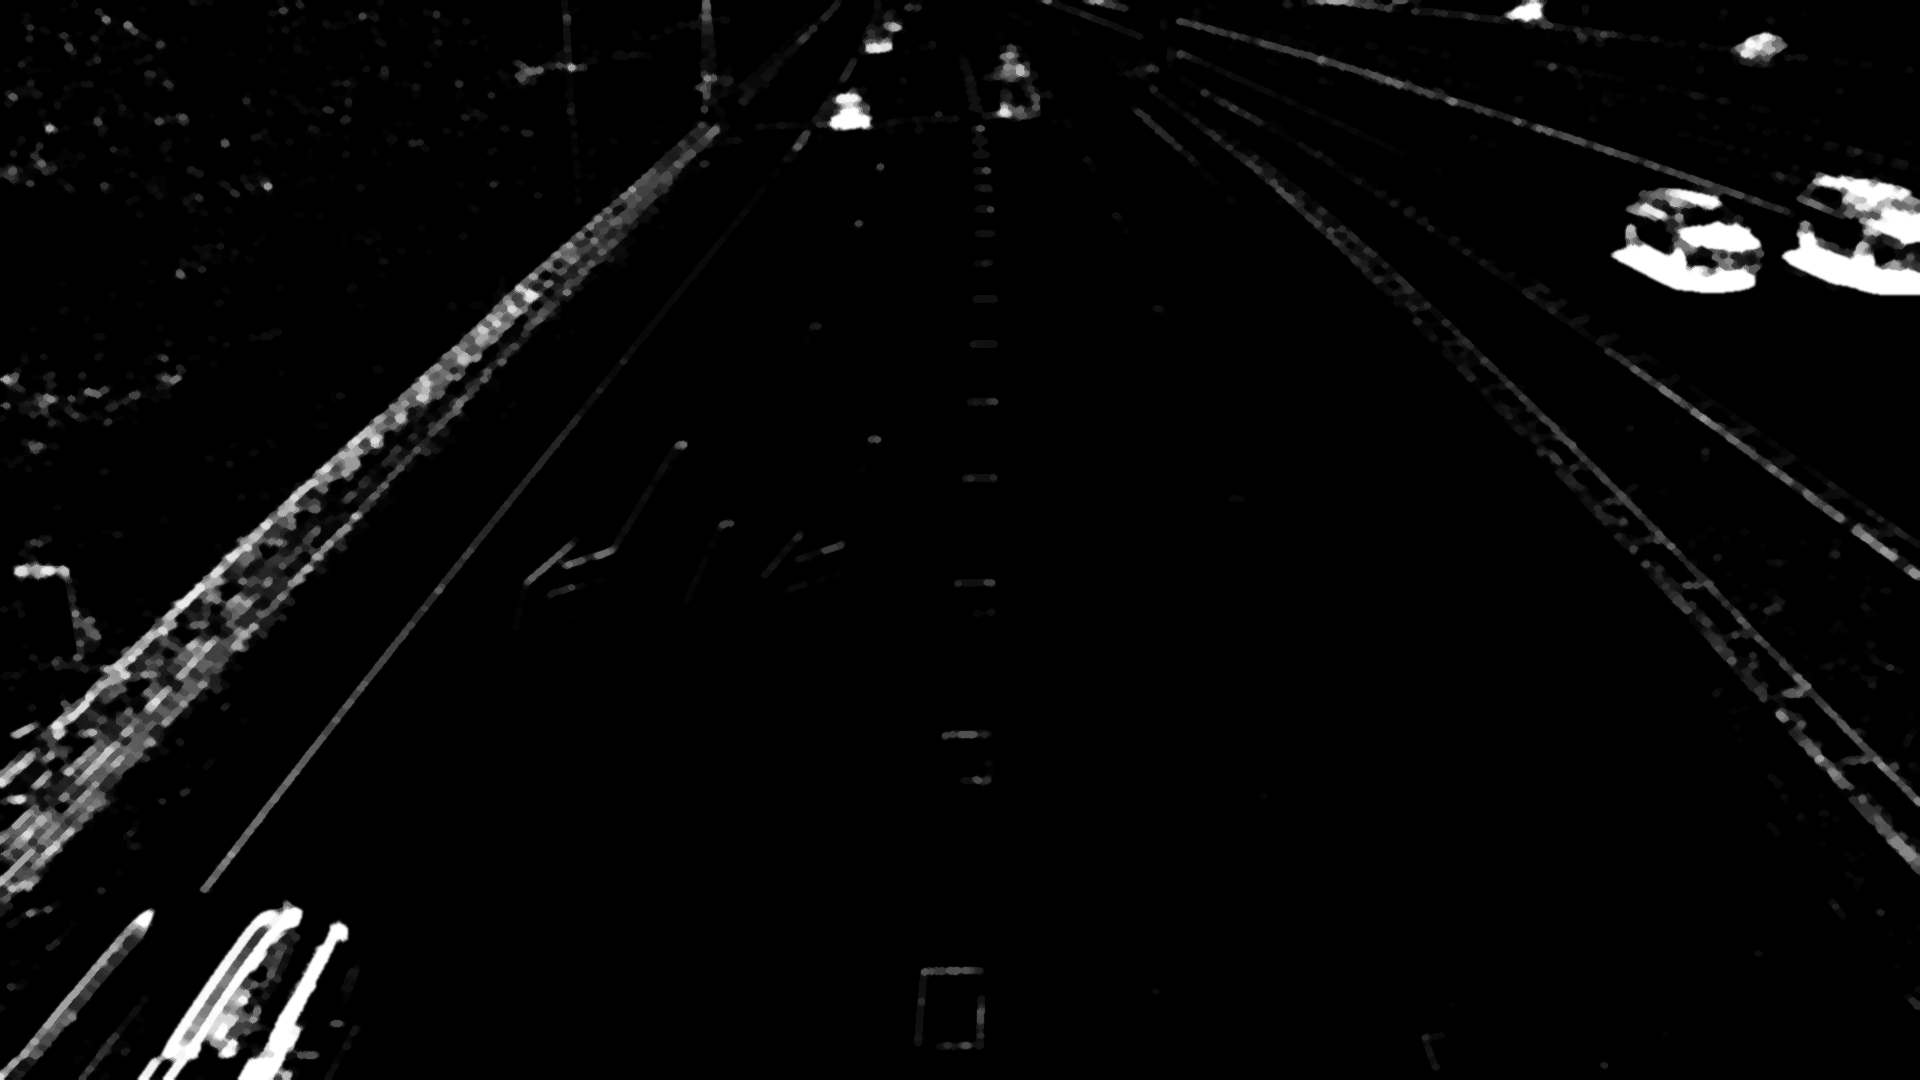

In [ ]:
import cv2
import numpy as np
from IPython.display import display, clear_output
from PIL import Image

# Load the video
cap = cv2.VideoCapture(r'C:\Users\Meena\Videos\cv_bg_sub.mp4')

# Initialize background subtractor (MOG2 is better for noise reduction)
bg_subtractor = cv2.createBackgroundSubtractorMOG2(detectShadows=True)

# Define kernel for morphological operations
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Apply background subtraction
    fg_mask = bg_subtractor.apply(frame)

    # Remove shadows (Optional, set detectShadows=False in MOG2 to avoid shadows)
    _, fg_mask = cv2.threshold(fg_mask, 200, 255, cv2.THRESH_BINARY)

    # Apply Gaussian Blur to remove noise
    fg_mask = cv2.GaussianBlur(fg_mask, (5, 5), 0)

    # Apply morphological opening (removes small noise)
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel)

    # Apply morphological closing (fills small holes)
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel)

    # Convert to displayable format
    fg_img = Image.fromarray(fg_mask)

    # Clear previous output and display new frame
    clear_output(wait=True)
    display(fg_img)

cap.release()


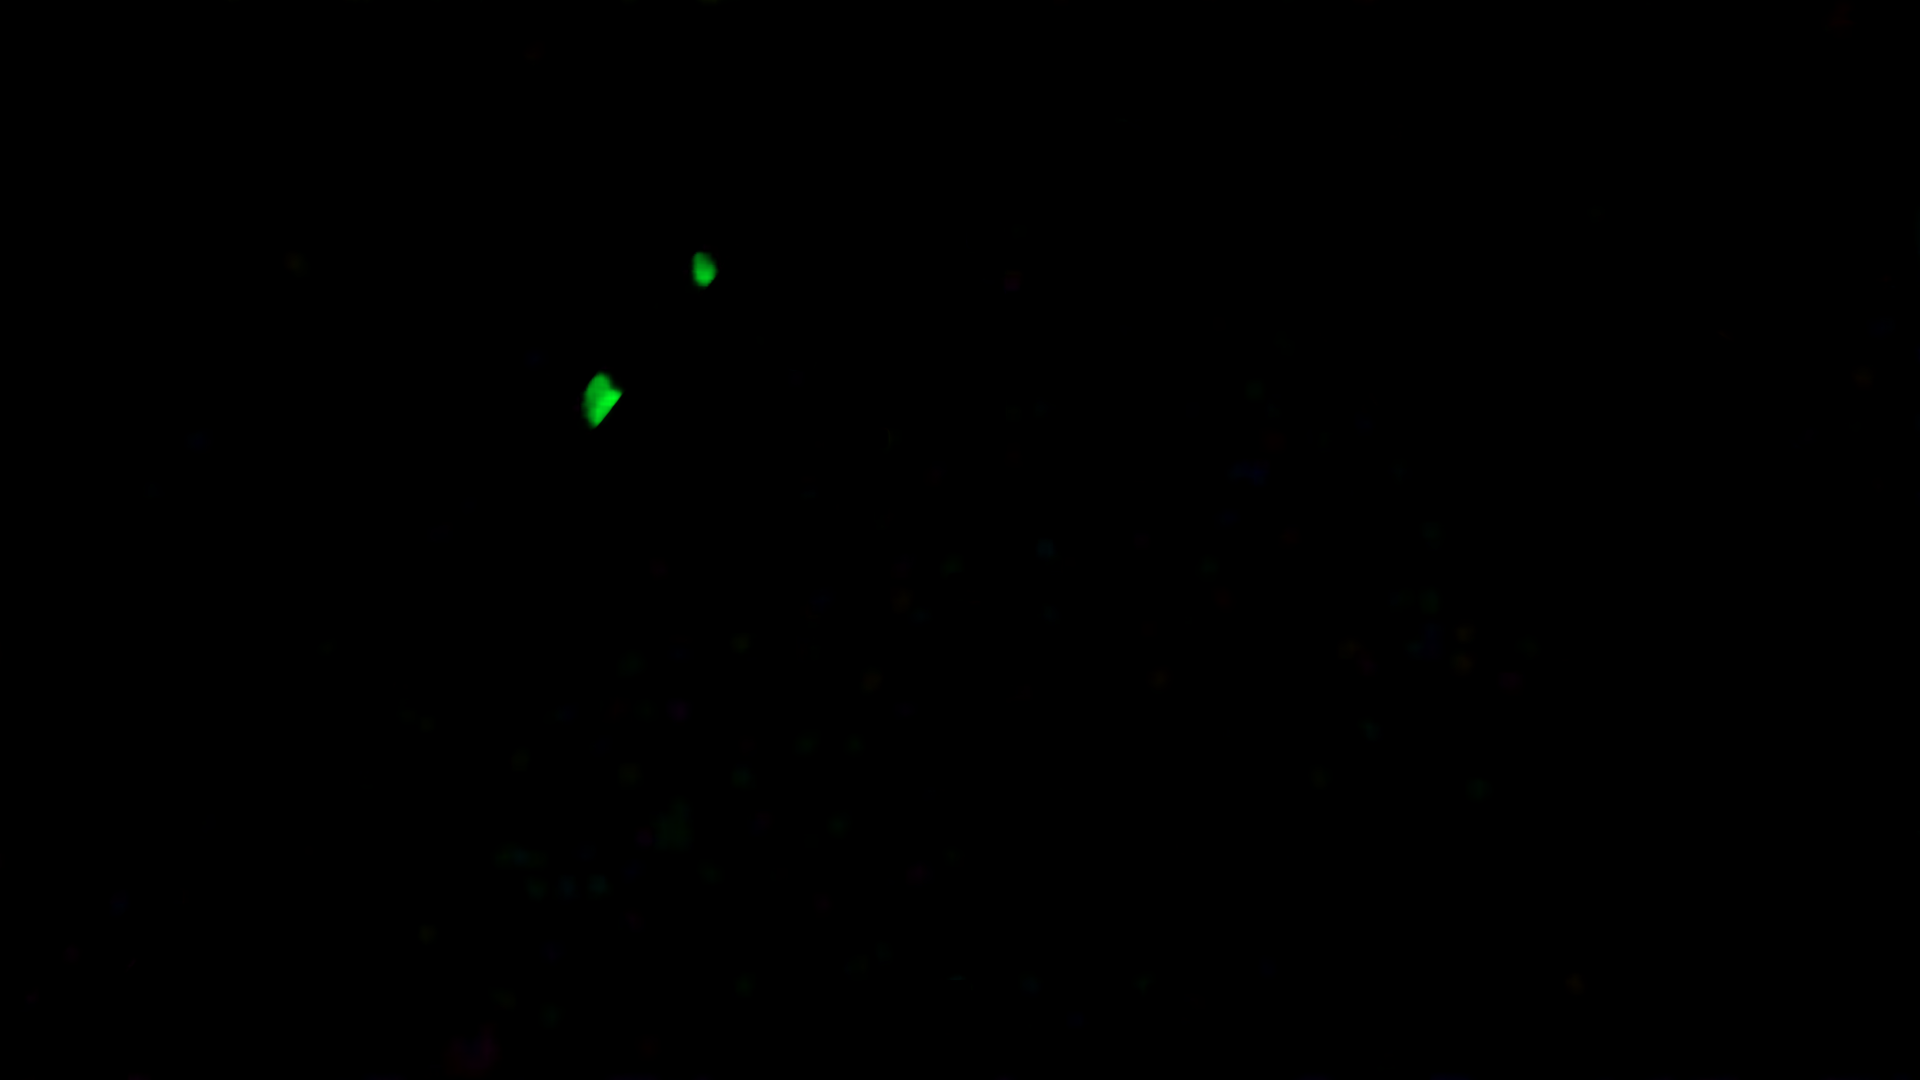

In [ ]:
import cv2
import numpy as np
from IPython.display import display, clear_output
from PIL import Image

# Load the video
cap = cv2.VideoCapture(r'C:\Users\Meena\Videos\cv_bg_sub.mp4')

# Read the first frame
ret, prev_frame = cap.read()
prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Convert to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Compute dense optical flow (Horn-Schunck)
    flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)

    # Convert flow to HSV representation
    hsv = np.zeros_like(frame)
    hsv[..., 1] = 255
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    hsv[..., 0] = ang * 180 / np.pi / 2
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    flow_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

    # Convert to displayable format and show in Jupyter Notebook
    img = Image.fromarray(flow_rgb)
    clear_output(wait=True)
    display(img)

    prev_gray = gray.copy()

cap.release()


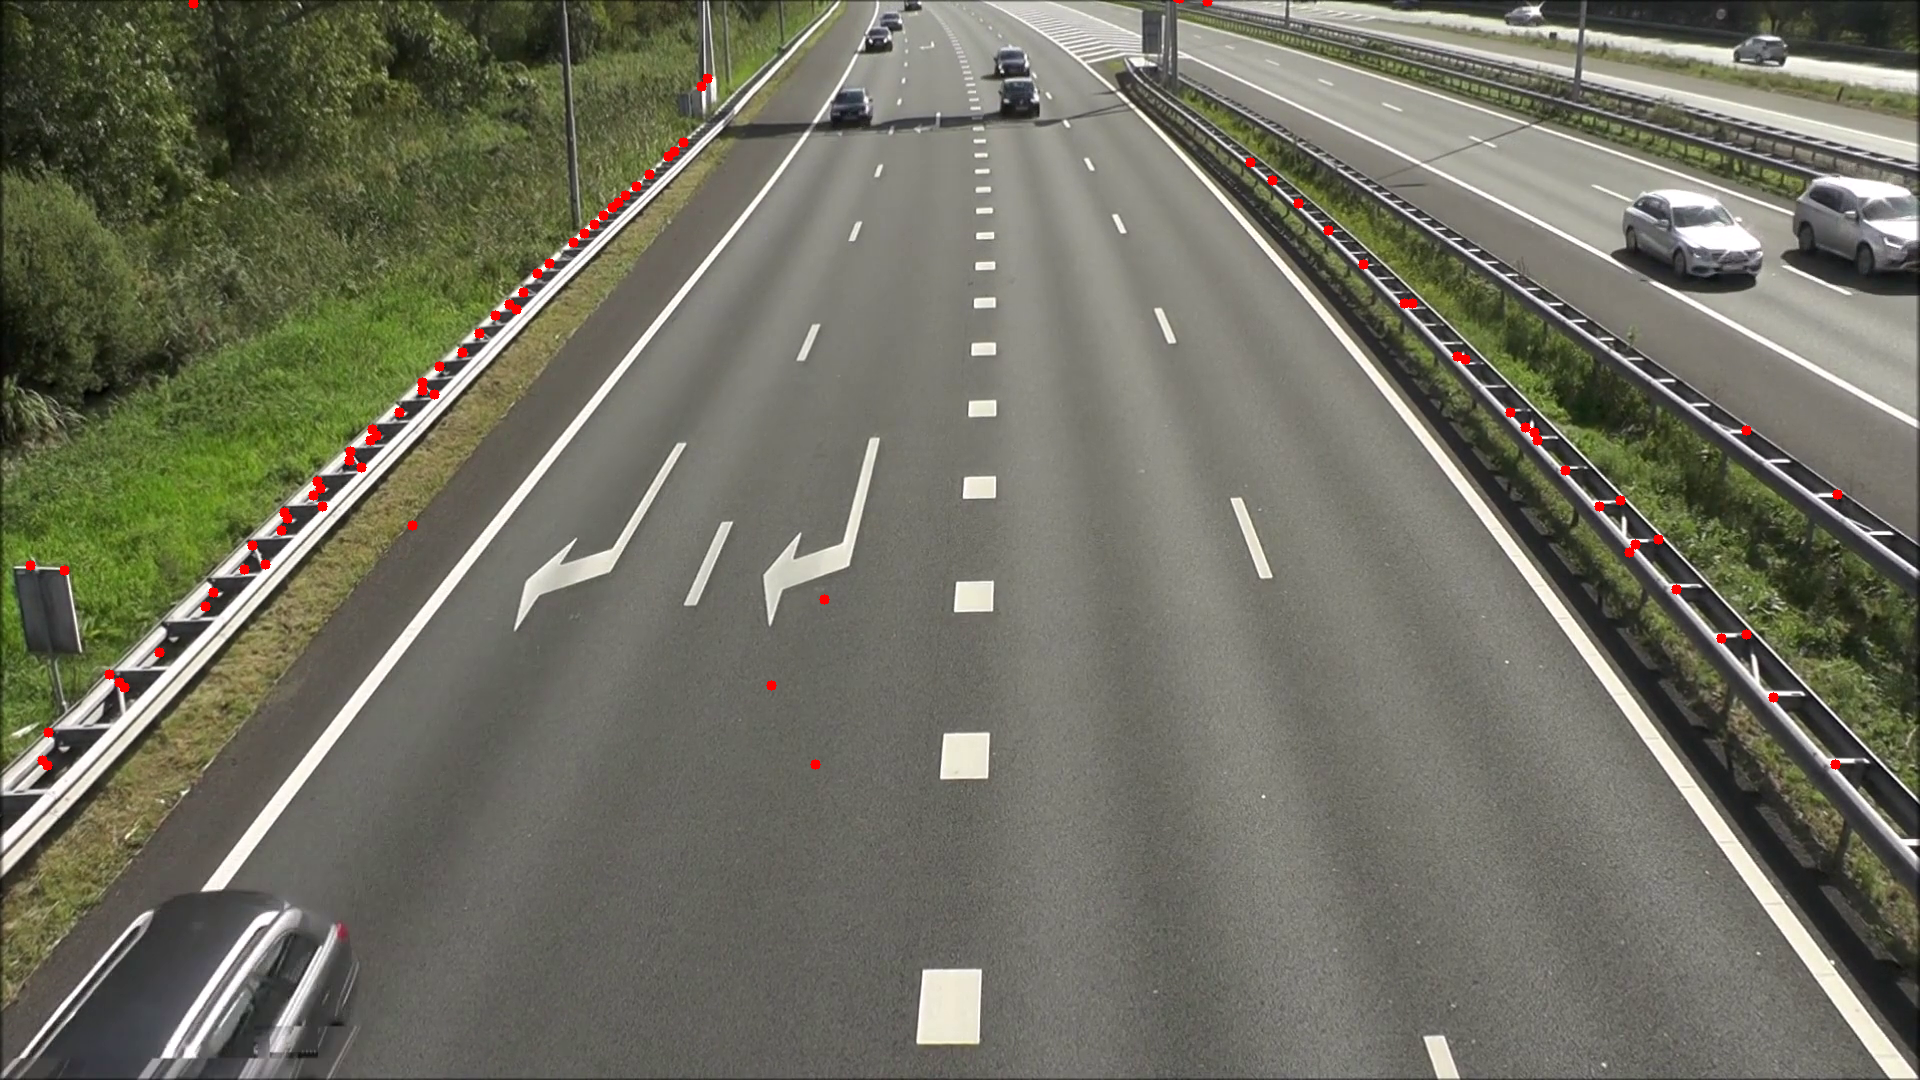

In [ ]:
import cv2
import numpy as np
from IPython.display import display, clear_output
from PIL import Image

# Load the video
cap = cv2.VideoCapture(r'C:\Users\Meena\Videos\cv_bg_sub.mp4')

# Parameters for Lucas-Kanade
lk_params = dict(winSize=(15, 15), maxLevel=2,
                 criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

# Read the first frame
ret, old_frame = cap.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

# Detect features to track
p0 = cv2.goodFeaturesToTrack(old_gray, maxCorners=100, qualityLevel=0.3, minDistance=7, blockSize=7)

# Process each frame
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Calculate optical flow
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)

    # Draw motion vectors
    if p1 is not None:
        for i, (new, old) in enumerate(zip(p1, p0)):
            a, b = new.ravel()
            c, d = old.ravel()
            cv2.line(frame, (int(a), int(b)), (int(c), int(d)), (0, 255, 0), 2)
            cv2.circle(frame, (int(a), int(b)), 5, (0, 0, 255), -1)

    # Update old frame and points
    old_gray = frame_gray.copy()
    p0 = p1[st == 1].reshape(-1, 1, 2)

    # Convert to displayable format and show in Jupyter Notebook
    img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    clear_output(wait=True)
    display(img)

cap.release()
